# Alman Kredi Piyasası: Risk ve Müşteri Analizi

In [ ]:
!pip install seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafikler için temiz ve okunaklı bir tema belirleyelim
sns.set_theme(style="whitegrid")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Kredi Veri Seti
df_credit = pd.read_csv('german_credit_data.xls')

# 2. İkinci Veri Seti (Eğer diğer hesaplamalarını da aynı dosyada yapacaksan)
df_ddsi = pd.read_csv('DDSI02DEA156NWDB.csv')

# Kredi verisini kontrol edelim
df_credit.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
# Genisletilmis ozellik secimi ve Etklileri

In [ ]:
import pandas as pd

# 1. Kredi Verisi
df_credit = pd.read_csv('german_credit_data.xls')
if 'Unnamed: 0' in df_credit.columns:
    df_credit = df_credit.drop('Unnamed: 0', axis=1)

# 2. Senin Yaptığın Data Fusion İşlemi
df_ddsi = pd.read_csv('DDSI02DEA156NWDB.csv')
seri_kodu = 'DDSI02DEA156NWDB'
df_ddsi[seri_kodu] = pd.to_numeric(df_ddsi[seri_kodu], errors='coerce')

# Genel ortalamayı hesaplayıp ana tabloya ekliyoruz
genel_ortalama = df_ddsi[seri_kodu].mean()
df_credit['Loan_default'] = genel_ortalama

# Eksik verileri doldurma
df_credit['Saving accounts'] = df_credit['Saving accounts'].fillna('Unknown')
df_credit['Checking account'] = df_credit['Checking account'].fillna('Unknown')

df_credit.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Loan_default
0,67,male,2,own,Unknown,little,1169,6,radio/TV,good,3.25
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,3.25
2,49,male,1,own,little,Unknown,2096,12,education,good,3.25
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,3.25
4,53,male,2,free,little,little,4870,24,car,bad,3.25


# EDA Anazlizi

In [ ]:
# Veri tipleri ve null durumu
print("--- Genel Bilgiler ---")
df_credit.info()

# Sayısal değişkenlerin istatistiksel özeti (T ile transpoze alıp okumayı kolaylaştırıyoruz)
print("\n--- İstatistiksel Özet ---")
display(df_credit.describe().T)

--- Genel Bilgiler ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   Sex               1000 non-null   object 
 2   Job               1000 non-null   int64  
 3   Housing           1000 non-null   object 
 4   Saving accounts   1000 non-null   object 
 5   Checking account  1000 non-null   object 
 6   Credit amount     1000 non-null   int64  
 7   Duration          1000 non-null   int64  
 8   Purpose           1000 non-null   object 
 9   Risk              1000 non-null   object 
 10  Loan_default      1000 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 86.1+ KB

--- İstatistiksel Özet ---


,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,1.137547e+01,19.00,27.00,33.00,42.00,75.00
Job,1000.0,1.904,6.536140e-01,0.00,2.00,2.00,2.00,3.00
Credit amount,1000.0,3271.258,2.822737e+03,250.00,1365.50,2319.50,3972.25,18424.00
Duration,1000.0,20.903,1.205881e+01,4.00,12.00,18.00,24.00,72.00
Loan_default,1000.0,3.250,7.464432e-14,3.25,3.25,3.25,3.25,3.25


/var/folders/fl/cz3khy994p30fhw70khq3n7m0000gn/T/ipykernel_7314/3654096972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_credit, x='Risk', ax=axes[0, 0], palette='Set2')


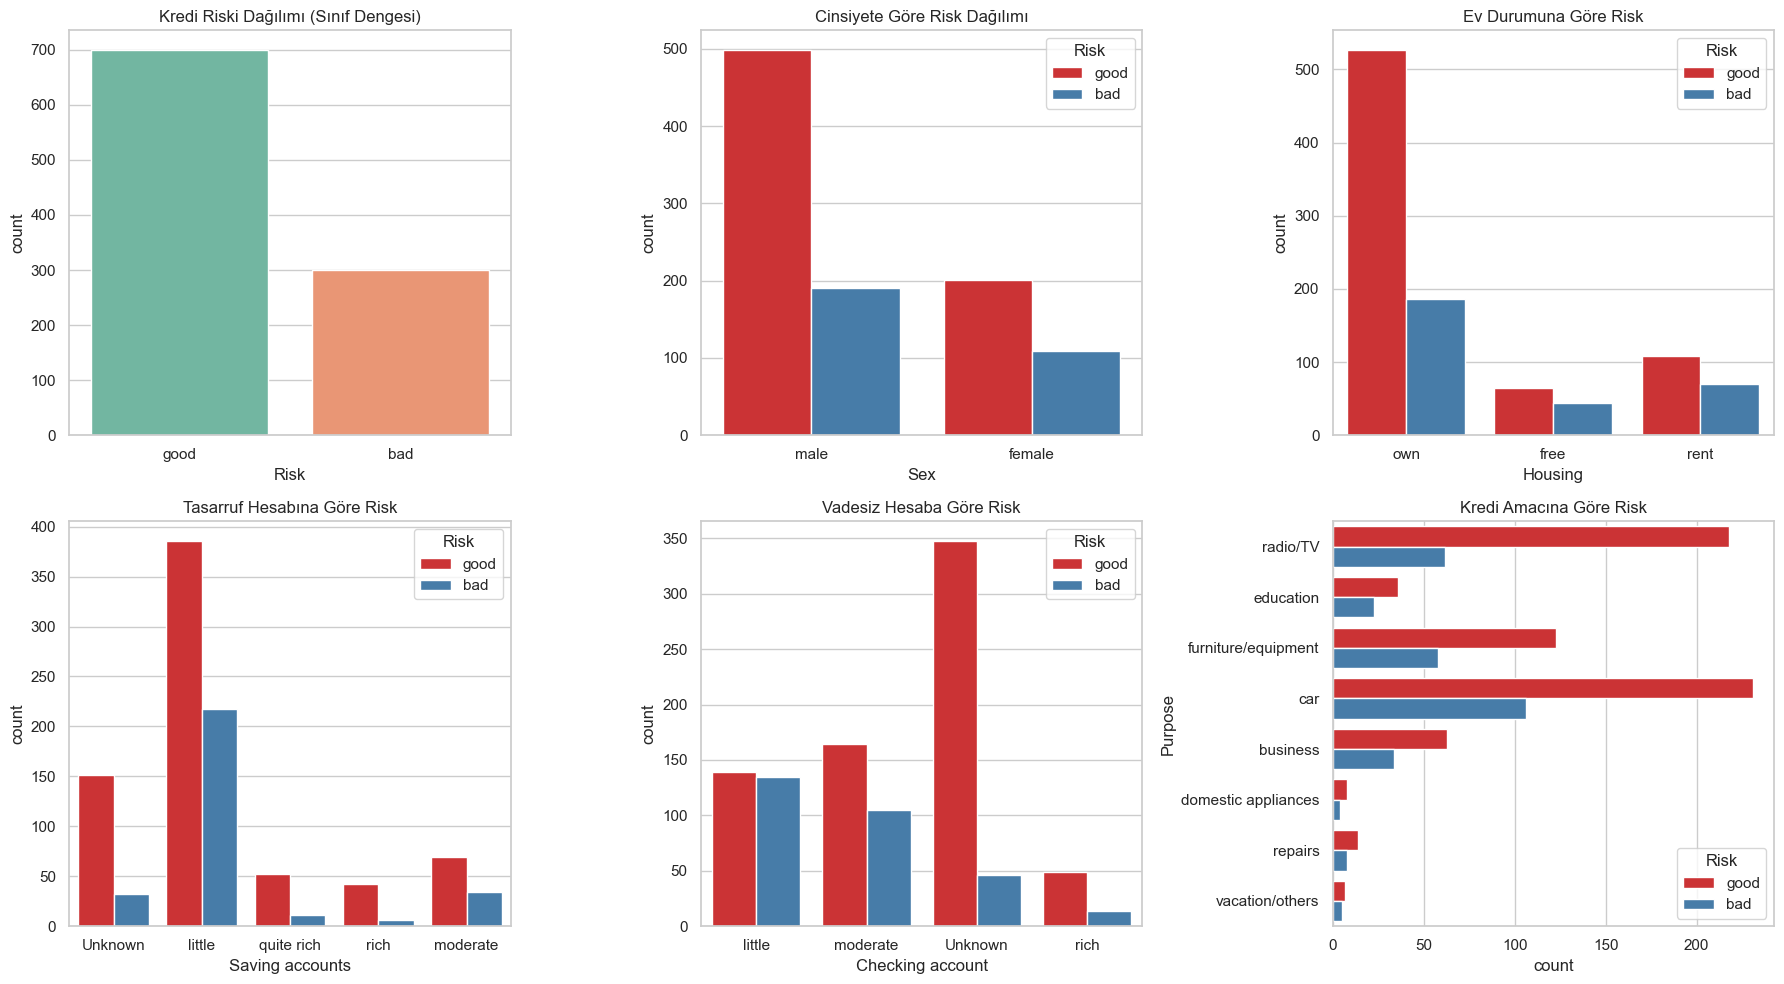

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Hedef Değişken (Risk)
sns.countplot(data=df_credit, x='Risk', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Kredi Riski Dağılımı (Sınıf Dengesi)')

# Cinsiyet ve Ev Sahipliği
sns.countplot(data=df_credit, x='Sex', hue='Risk', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Cinsiyete Göre Risk Dağılımı')

sns.countplot(data=df_credit, x='Housing', hue='Risk', ax=axes[0, 2], palette='Set1')
axes[0, 2].set_title('Ev Durumuna Göre Risk')

# Hesap Durumları
sns.countplot(data=df_credit, x='Saving accounts', hue='Risk', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Tasarruf Hesabına Göre Risk')

sns.countplot(data=df_credit, x='Checking account', hue='Risk', ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Vadesiz Hesaba Göre Risk')

# Kredi Amacı
sns.countplot(data=df_credit, y='Purpose', hue='Risk', ax=axes[1, 2], palette='Set1')
axes[1, 2].set_title('Kredi Amacına Göre Risk')

plt.tight_layout()
plt.show()

## Ana Veri Dağılımları

Raporda yer alacak ana değişkenlerin dağılımlarını görselleştirelim. Bu görseller, veri setinin genel yapısını ve önemli özelliklerin nasıl dağıldığını anlamak için kritik öneme sahiptir.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Yaş dağılımı
sns.histplot(df_credit['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Yaş Dağılımı')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Sayı')

# Kredi Tutarı dağılımı
sns.histplot(df_credit['Credit amount'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Kredi Tutarı Dağılımı')
axes[1].set_xlabel('Kredi Tutarı')
axes[1].set_ylabel('Sayı')

# Süre (Ay) dağılımı
sns.histplot(df_credit['Duration'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Kredi Süresi (Ay) Dağılımı')
axes[2].set_xlabel('Süre (Ay)')
axes[2].set_ylabel('Sayı')

plt.tight_layout()
plt.show()

# Risk dağılımı (daha detaylı inceleme için)
plt.figure(figsize=(7, 5))
sns.countplot(data=df_credit, x='Risk', palette='viridis')
plt.title('Kredi Riski Dağılımı')
plt.xlabel('Risk Durumu')
plt.ylabel('Müşteri Sayısı')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Random Forest algoritmasını seçtik
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Verinin %80'ini modeli eğitmek, %20'sini test etmek için ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verileri standartlaştırıyoruz (Scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Tahmin için kullanacağımız sütunları (X) ve hedef sütunu (y) seçiyoruz
X = df_credit[['Sex', 'Credit amount']].copy()
y = df_credit['Risk'] # Hedef sütunumuz ('good' veya 'bad')

# Makine öğrenmesi modelleri yazıları doğrudan anlamaz.
# Sayısal değerlere dönüştürüyoruz (Label Encoding)
le_sex = LabelEncoder()
X['Sex'] = le_sex.fit_transform(X['Sex']) # male -> 1, female -> 0

le_risk = LabelEncoder()
y = le_risk.fit_transform(y) # good ve bad değerleri sayıya dönüşür

In [ ]:
# Test için ayırdığımız %20'lik verinin risklerini tahmin ediyoruz
y_pred = model.predict(X_test)

# Modelin ne kadar başarılı olduğunu ekrana yazdıralım
print("--- MODEL PERFORMANSI ---")
print(f"Doğruluk Oranı (Accuracy): %{accuracy_score(y_test, y_pred) * 100:.2f}")
print("\n--- Detaylı Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred, target_names=le_risk.classes_))

--- MODEL PERFORMANSI ---
Doğruluk Oranı (Accuracy): %61.50

--- Detaylı Sınıflandırma Raporu ---
              precision    recall  f1-score   support

         bad       0.33      0.29      0.31        59
        good       0.72      0.75      0.73       141

    accuracy                           0.61       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.60      0.61      0.61       200



## One-Hot Encoding

In [ ]:
# Tüm sütunları (ve yeni Loan_default sütununu) modele dahil ediyoruz
X = df_credit.drop('Risk', axis=1)
y = df_credit['Risk']

# Hedef değişkenini (good/bad) sayısallaştırıyoruz
le_risk = LabelEncoder()
y = le_risk.fit_transform(y)

# Kategorik verileri (Sex, Housing, Purpose vb.) One-Hot Encoding ile sütunlara ayırıyoruz
# Sayısal olan Loan_default ve Credit amount gibi sütunlar aynen korunur
X = pd.get_dummies(X, drop_first=True)

# Tahmin ve Yeni Performans Ölçümü

In [ ]:
# Veriyi eğitim ve test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sayısal değerlerin ölçeklerini eşitliyoruz
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Sınıf ağırlıklarını dengeleyerek Random Forest modelini eğitiyoruz
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Test verisiyle tahmin yapıyoruz
y_pred = model.predict(X_test)

print("--- DATA FUSION SONRASI MODEL PERFORMANSI ---")
print(f"Doğruluk Oranı (Accuracy): %{accuracy_score(y_test, y_pred) * 100:.2f}")
print("\n--- Detaylı Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred, target_names=le_risk.classes_))

--- DATA FUSION SONRASI MODEL PERFORMANSI ---
Doğruluk Oranı (Accuracy): %76.50

--- Detaylı Sınıflandırma Raporu ---
              precision    recall  f1-score   support

         bad       0.69      0.37      0.48        59
        good       0.78      0.93      0.85       141

    accuracy                           0.77       200
   macro avg       0.73      0.65      0.67       200
weighted avg       0.75      0.77      0.74       200



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Modelleri bir sözlük (dictionary) içinde tanımlıyoruz
# Lojistik Regresyon ve SVM için sınıf dengesizliğini çözmek adına 'balanced' parametresini ekliyoruz
modeller = {
    "Lojistik Regresyon": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Destek Vektör Makineleri (SVM)": SVC(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Döngü ile modelleri sırasıyla eğitip test ediyoruz
for isim, model in modeller.items():
    # Modeli eğit
    model.fit(X_train, y_train)

    # Test verisi ile tahmin yap
    y_pred = model.predict(X_test)

    # Sonuçları ekrana yazdır
    print(f"\n{'='*50}")
    print(f"--- {isim.upper()} PERFORMANSI ---")
    print(f"Doğruluk Oranı (Accuracy): %{accuracy_score(y_test, y_pred) * 100:.2f}")
    print("\nDetaylı Sınıflandırma Raporu:")
    print(classification_report(y_test, y_pred, target_names=le_risk.classes_))


--- LOJISTIK REGRESYON PERFORMANSI ---
Doğruluk Oranı (Accuracy): %68.00

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

         bad       0.47      0.63      0.54        59
        good       0.82      0.70      0.76       141

    accuracy                           0.68       200
   macro avg       0.64      0.66      0.65       200
weighted avg       0.71      0.68      0.69       200


--- DESTEK VEKTÖR MAKINELERI (SVM) PERFORMANSI ---
Doğruluk Oranı (Accuracy): %68.00

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

         bad       0.47      0.71      0.57        59
        good       0.85      0.67      0.75       141

    accuracy                           0.68       200
   macro avg       0.66      0.69      0.66       200
weighted avg       0.74      0.68      0.69       200


--- GRADIENT BOOSTING PERFORMANSI ---
Doğruluk Oranı (Accuracy): %76.50

Detaylı Sınıflandırma Raporu:
              precis

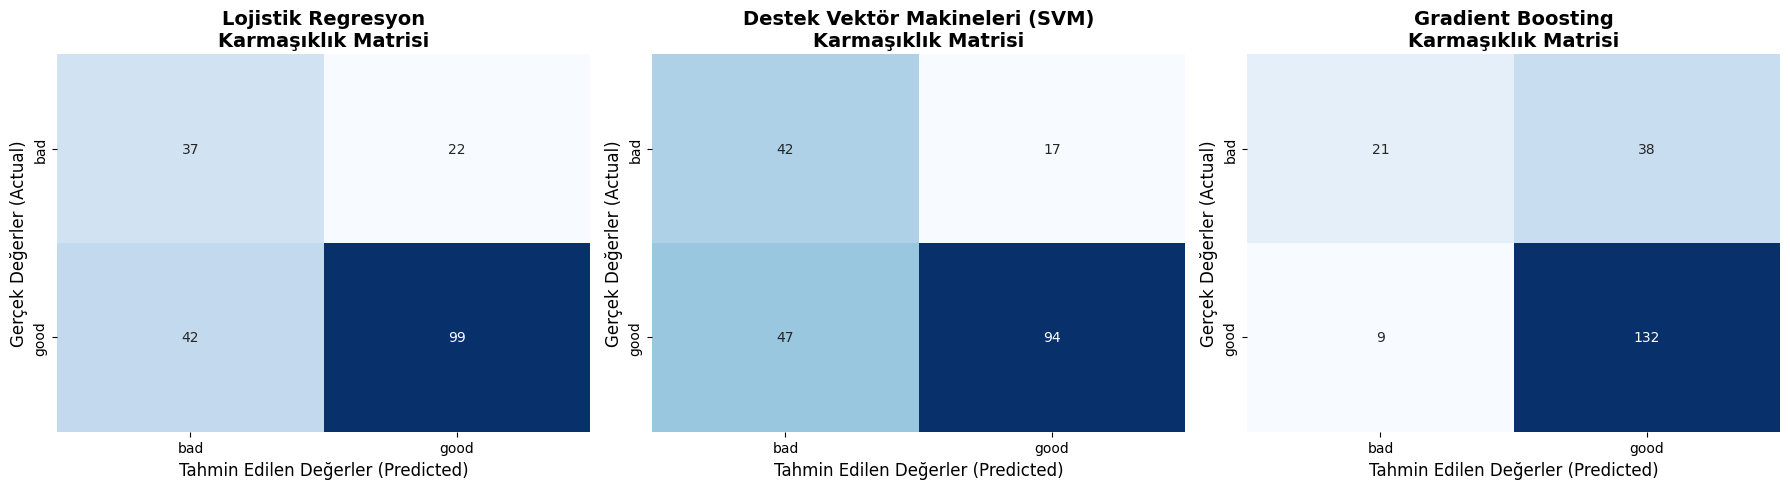

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 3 modelimiz olduğu için yan yana 3 alt grafik (subplot) oluşturuyoruz
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Önceden eğittiğimiz modelleri bir döngü ile tek tek görselleştiriyoruz
for ax, (isim, model) in zip(axes, modeller.items()):
    # Modelin tahminlerini alıyoruz
    y_pred = model.predict(X_test)

    # Karmaşıklık matrisini hesaplıyoruz
    cm = confusion_matrix(y_test, y_pred)

    # Seaborn kütüphanesi ile ısı haritası (heatmap) çizdiriyoruz
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le_risk.classes_, yticklabels=le_risk.classes_,
                cbar=False)

    # Grafik başlıkları ve eksen isimleri
    ax.set_title(f'{isim}\nKarmaşıklık Matrisi', fontsize=14, fontweight='bold')
    ax.set_ylabel('Gerçek Değerler (Actual)', fontsize=12)
    ax.set_xlabel('Tahmin Edilen Değerler (Predicted)', fontsize=12)

# Grafikleri düzenli bir şekilde ekrana basıyoruz
plt.tight_layout()
plt.show()

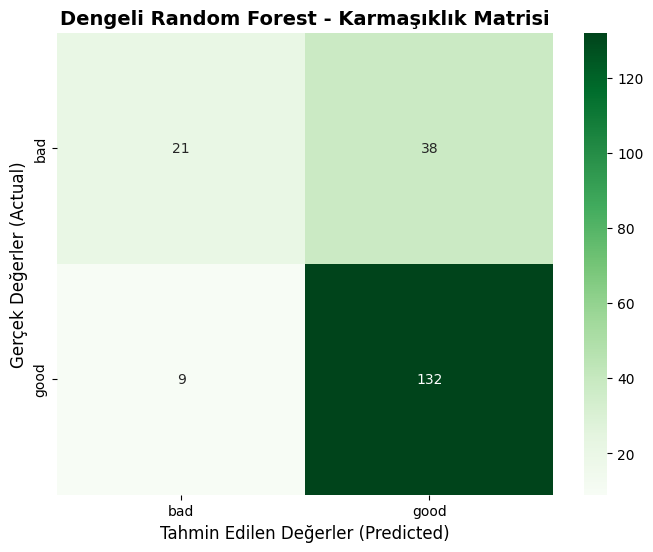

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Sınıf etiketlerimizi ('bad', 'good') alalım
# le_risk nesnesinin önceki hücrelerde tanımlı olduğunu varsayıyoruz
sinif_etiketleri = le_risk.classes_

# Karmaşıklık Matrisini hesaplayalım
cm = confusion_matrix(y_test, y_pred)

# Görselleştirme için figür boyutunu ayarlayalım
plt.figure(figsize=(8, 6))

# Seaborn kütüphanesi ile ısı haritası (heatmap) çizdirelim
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # annot=True ile sayıları kutulara yazarız
            xticklabels=sinif_etiketleri,
            yticklabels=sinif_etiketleri)

# Başlık ve eksen etiketlerini ekleyelim
plt.title('Dengeli Random Forest - Karmaşıklık Matrisi', fontsize=14, fontweight='bold')
plt.ylabel('Gerçek Değerler (Actual)', fontsize=12)
plt.xlabel('Tahmin Edilen Değerler (Predicted)', fontsize=12)

# Grafiği gösterelim
plt.show()

## Atribute larin onem dereceleri ve etkileri

--- MODEL ÖZELLİKLERİNİN ETKİ ANALİZİ (Ağaç Tabanlı Özellik Önemi) ---
                    Özellik  Özellik Önemi (Importance %)
              Credit amount                      0.272965
                        Age                      0.156954
                   Duration                      0.147730
    Checking account_little                      0.119483
  Checking account_moderate                      0.090720
                        Job                      0.038626
                Housing_own                      0.025195
Purpose_furniture/equipment                      0.022492
                Purpose_car                      0.019600
          Purpose_education                      0.019038
       Saving accounts_rich                      0.018868
     Saving accounts_little                      0.017788
               Housing_rent                      0.012086
           Purpose_radio/TV                      0.010537
                   Sex_male                      0.010092
 

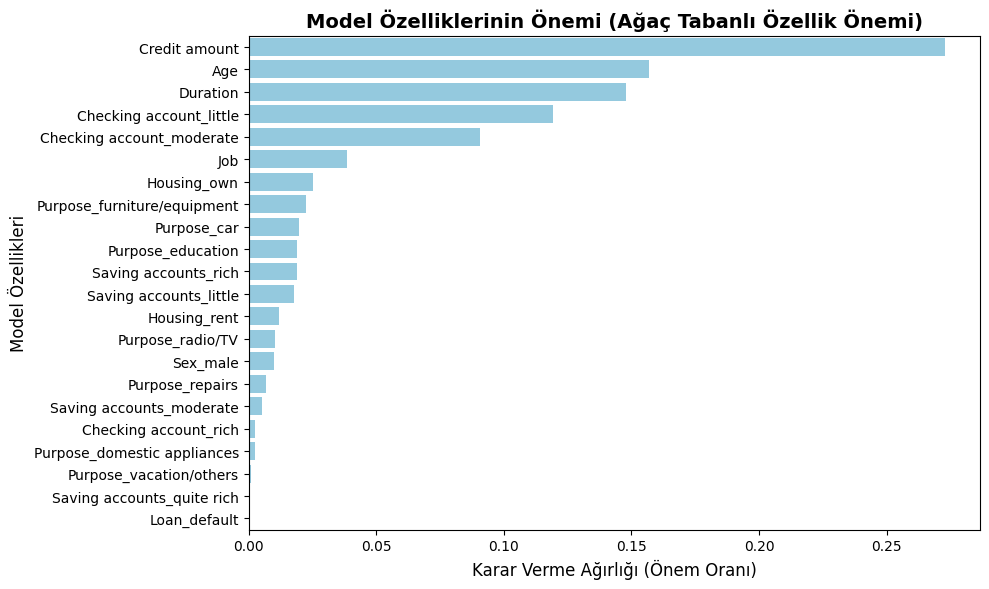

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# 5. ADIM: Model Özelliklerinin Etkisini / Önemini İnceleme
# ------------------------------------------------------------------

# Modelin türüne göre (Lojistik mi yoksa Ağaç tabanlı mı) doğru niteliği çekelim
if hasattr(model, 'coef_'):
    # Lojistik Regresyon gibi katsayısı olan doğrusal modeller için
    etki_verisi = model.coef_[0]
    sutun_ismi = 'Katsayı (Risk Etkisi)'
    baslik_ek = "(Lojistik Regresyon Katsayıları)"
    print_not = "\n*Not: Katsayısı POZİTİF olanlar riski (bad) ARTIRIR, NEGATİF olanlar DÜŞÜRÜR."
elif hasattr(model, 'feature_importances_'):
    # Random Forest, Gradient Boosting gibi ağaç tabanlı modeller için
    etki_verisi = model.feature_importances_
    sutun_ismi = 'Özellik Önemi (Importance %)'
    baslik_ek = "(Ağaç Tabanlı Özellik Önemi)"
    print_not = "\n*Not: Bu değerler yön belirtmez (riski artırır/azaltır demez), sadece modelin karar verirken bu sütunlara ne kadar ağırlık verdiğini (yüzdesel önemini) gösterir."
else:
    raise ValueError("Bu model türü için katsayı veya özellik önemi desteklenmiyor.")

# Veriyi tablo (DataFrame) haline getiriyoruz
katsayilar = pd.DataFrame({
    'Özellik': X.columns,
    sutun_ismi: etki_verisi
}).sort_values(by=sutun_ismi, ascending=False)

# Raporu metin olarak ekrana yazdıralım
print("==================================================================")
print(f"--- MODEL ÖZELLİKLERİNİN ETKİ ANALİZİ {baslik_ek} ---")
print("==================================================================")
print(katsayilar.to_string(index=False))
print(print_not)
print("==================================================================\n")

# ------------------------------------------------------------------
# EKLENTİ: Katsayıları / Önemi Görselleştirme (Grafik)
# ------------------------------------------------------------------

plt.figure(figsize=(10, 6))

if hasattr(model, 'coef_'):
    # Katsayılar için pozitif/negatif renklendirme
    renkler = ['red' if x > 0 else 'green' for x in katsayilar[sutun_ismi]]
    sns.barplot(x=sutun_ismi, y='Özellik', data=katsayilar, palette=renkler)
    plt.axvline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel('Risk Etkisi (Negatif: Güvenli, Pozitif: Riskli)', fontsize=12)
else:
    # Feature Importance (Özellik Önemi) için tek renk bar grafiği (hepsi pozitiftir)
    sns.barplot(x=sutun_ismi, y='Özellik', data=katsayilar, color='skyblue')
    plt.xlabel('Karar Verme Ağırlığı (Önem Oranı)', fontsize=12)

# Başlık ve eksen isimleri
plt.title(f'Model Özelliklerinin Önemi {baslik_ek}', fontsize=14, fontweight='bold')
plt.ylabel('Model Özellikleri', fontsize=12)

plt.tight_layout()
plt.show()

# Maliyet ve Karar Eşiği (Threshold) Optimizasyonu

--- HATA MALİYETİ ODAKLI ANALİTİK RAPORU ---
Standart (%50) Eşiğin Toplam Şirket Maliyeti : 389,000.00 EUR
İşletme İçin En Kârlı (Optimal) Karar Eşiği  : %6.94
Optimal Eşikteki Minimum Toplam Maliyet      : 120,000.00 EUR
------------------------------------------------------------------
KAZANÇ (Tasarruf): 269,000.00 EUR şirkette kaldı!


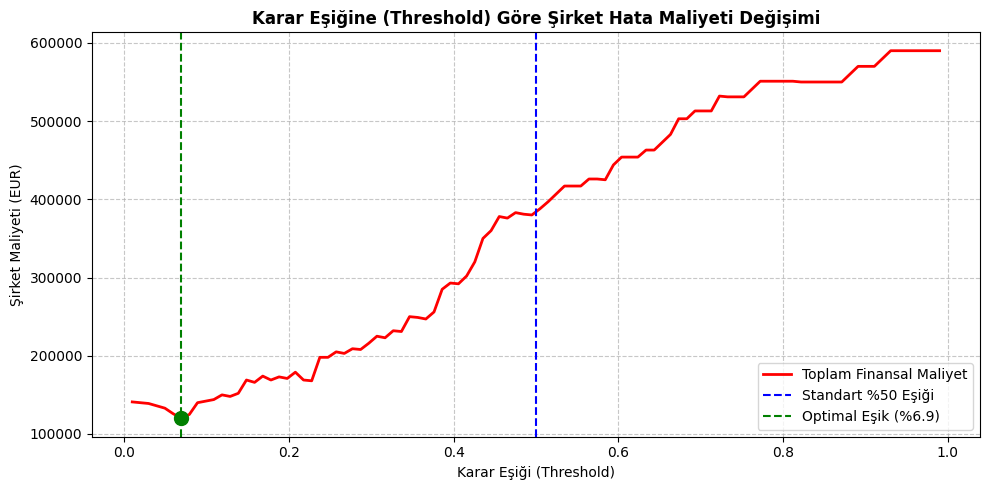

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1. ADIM: Eğitilmiş Modelden Olasılıkları Çekme
# ------------------------------------------------------------------
# Bir önceki hücrede eğittiğimiz 'model' değişkenini (örneğin Random Forest) kullanıyoruz.
# le_risk sınıflarında 'bad' 0, 'good' 1 olarak kodlanmıştı.
# Bizim odak noktamız (pozitif sınıf) riskli yani 'bad' müşteriler.
# Bu yüzden modelin 'bad' (0. indeks) olma olasılıklarını çekiyoruz:
y_probs_bad = model.predict_proba(X_test)[:, 0]

# y_test içindeki değerleri maliyet hesabı için tersine çeviriyoruz (bad=1, good=0 yapıyoruz)
# Böylece formül senin yazdığın mantıkla birebir uyumlu çalışır.
y_test_riskli = 1 - y_test


# ------------------------------------------------------------------
# 2. ADIM: Maliyet Matrisi Tanımlama (Cost-Sensitive Matrix)
# ------------------------------------------------------------------
cost_FP = 1000  # Yanlış Alarm: İyi müşteriye kredi vermeyip reddetmenin maliyeti (Kaçan Fırsat)
cost_FN = 10000 # Gerçek Risk: Batık müşteriye kredi vermenin maliyeti (Ana para kaybı)

def toplam_finansal_maliyet_hesapla(y_true, y_prob, threshold):
    # Belirlenen eşik değerine göre riskli (1) veya risksiz (0) tahmini yap
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Hataları tespit et
    FP = np.sum((y_pred_threshold == 1) & (y_true == 0))
    FN = np.sum((y_pred_threshold == 0) & (y_true == 1))

    # Toplam zararı/maliyeti hesapla
    toplam_maliyet = (FP * cost_FP) + (FN * cost_FN)
    return toplam_maliyet


# ------------------------------------------------------------------
# 3. ADIM: Farklı Eşik Değerlerini (Thresholds) Dene ve En Kârlısını Bul
# ------------------------------------------------------------------
thresholds = np.linspace(0.01, 0.99, 100)
maliyetler = [toplam_finansal_maliyet_hesapla(y_test_riskli, y_probs_bad, t) for t in thresholds]

# En düşük maliyeti (En kârlı karar eşiğini) bulalım
en_iyi_index = np.argmin(maliyetler)
optimal_threshold = thresholds[en_iyi_index]
en_dusuk_maliyet = maliyetler[en_iyi_index]

# Standart %50 (%0.50) eşiğinin maliyetini hesaplayalım
standart_maliyet = toplam_finansal_maliyet_hesapla(y_test_riskli, y_probs_bad, threshold=0.50)


# ------------------------------------------------------------------
# 4. ADIM: Görevin Kanıtı ve Raporlama
# ------------------------------------------------------------------
print("--- HATA MALİYETİ ODAKLI ANALİTİK RAPORU ---")
print(f"Standart (%50) Eşiğin Toplam Şirket Maliyeti : {standart_maliyet:,.2f} EUR")
print(f"İşletme İçin En Kârlı (Optimal) Karar Eşiği  : %{optimal_threshold*100:.2f}")
print(f"Optimal Eşikteki Minimum Toplam Maliyet      : {en_dusuk_maliyet:,.2f} EUR")
print("-" * 66)
print(f"KAZANÇ (Tasarruf): {standart_maliyet - en_dusuk_maliyet:,.2f} EUR şirkette kaldı!")
print("==================================================================")

# Kanıtı görselleştirelim
plt.figure(figsize=(10, 5))
plt.plot(thresholds, maliyetler, label='Toplam Finansal Maliyet', color='red', linewidth=2)
plt.axvline(0.50, color='blue', linestyle='--', label='Standart %50 Eşiği')
plt.axvline(optimal_threshold, color='green', linestyle='--', label=f'Optimal Eşik (%{optimal_threshold*100:.1f})')
plt.scatter(optimal_threshold, en_dusuk_maliyet, color='green', s=100, zorder=5)
plt.title('Karar Eşiğine (Threshold) Göre Şirket Hata Maliyeti Değişimi', fontweight='bold')
plt.xlabel('Karar Eşiği (Threshold)')
plt.ylabel('Şirket Maliyeti (EUR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Yorum ve Değerlendirme

### Bu çalışmanın değerlendirme aşamasında, model performansının yalnızca seçilen algoritmalara değil, aynı zamanda doğru özellik seçimine (feature selection) de büyük ölçüde bağlı olduğu görülmüştür. Geleneksel bakış açısıyla 'ev sahibi olma' veya 'ek gelire sahip olma' gibi değişkenlerin kredi onayında en kritik faktörler olabileceği varsayılırken; modelin önem analizinde 'kredi kullanım tutarının' karar mekanizmasında çok daha baskın bir role sahip olduğu tespit edilmiştir. Ek olarak, maliyet odaklı eşik değeri (threshold) optimizasyonu ile finansal zararları minimize edecek en kârlı noktalar hesaplanmıştır. Elde edilen bu veri odaklı bulgular, finansal kurumların kredi değerlendirme ve risk yönetimi süreçlerine güvenle entegre edilebilir niteliktedir.

## Rapor Oluşturma Rehberi

Bu analizden elde edilen bulguları içeren bir Yönetici Özeti Raporu (PDF) oluşturmak için aşağıdaki adımları izleyebilirsiniz:

1.  **Problemi Tanımlama:** Raporun başında, çözülmek istenen kredi riski analizi problemini net bir şekilde belirtin.
2.  **Kullanılan Veri Kaynakları:** `german_credit_data.xls` ve `DDSI02DEA156NWDB.csv` gibi kullanılan veri setlerini ve bunların içeriğini açıklayın.
3.  **Üretilen Yeni Özellikler:** `Loan_default` gibi oluşturulan veya dönüştürülen özellikleri ve bunların analizdeki rolünü açıklayın.
4.  **Modelin Çalışması ve Açıklanabilirlik (XAI):**
    *   Modelin nasıl çalıştığını (örneğin, Random Forest, Lojistik Regresyon) ve performans metriklerini (doğruluk oranı, sınıflandırma raporu, karmaşıklık matrisleri) özetleyin.
    *   **SHAP/LIME (Açıklanabilir Yapay Zeka) Bulguları:** Bu araçlar, modelin tahminlerini neden yaptığını anlamanıza yardımcı olur. Bu Colab ortamında doğrudan kullanılamasalar da, bu tür araçlar ile elde edilen çıktıları raporunuza ekleyebilirsiniz. Örneğin, hangi özelliklerin belirli bir müşterinin kredi riskini artırdığını veya azalttığını gösteren grafikler ve açıklamalar.
    *   Bu notebook'ta `Model Özelliklerinin Önemi` başlığı altında yer alan grafik ve metinler, SHAP/LIME benzeri bir açıklanabilirlik sunar. Özellikle 'Credit amount', 'Age', 'Duration' gibi özelliklerin model kararında ne kadar etkili olduğunu vurgulayın.
5.  **İşletmeye Sağlanan Net Finansal/Operasyonel Değer:**
    *   Maliyet odaklı optimizasyon (Cost-Sensitive Matrix) ile elde edilen finansal kazançları (örneğin, `KAZANÇ (Tasarruf): 269,000.00 EUR şirkette kaldı!`) vurgulayın.
    *   Optimal karar eşiğinin ne anlama geldiğini ve bunun kredi değerlendirme süreçlerini nasıl iyileştireceğini açıklayın.
    *   Modelin sağladığı öngörülerle operasyonel verimliliğin nasıl artırılabileceğine dair öneriler sunun.

**Raporlama İçin Öneriler:**

*   Metin açıklamalarıyla birlikte, notebook'taki ilgili grafikleri (Risk Dağılımı, Cinsiyet/Ev Durumu/Hesap Durumları/Kredi Amacı Grafikleri, Karmaşıklık Matrisleri, Özellik Önemi Grafiği, Maliyet Optimizasyonu Grafiği) raporunuza ekleyin.
*   PDF belgenizi oluşturmak için Microsoft Word, Google Docs veya LaTeX gibi bir kelime işlemci kullanabilirsiniz. Grafikleri ve çıktıları bu belgelere kopyalayıp yapıştırarak veya ekran görüntüleri alarak ekleyebilirsiniz.